In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk

In [2]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_v6.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,Mvir2,Mvir2_err,star_sigma2,star_sigma2_err,e_Mstar_R90,BPT_class,sum_M_star_0p1_R90,count_M_star_0p1_R90
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float

In [3]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [4]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [5]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/results_plots/refit_spirals/'

In [6]:
ellipticals = master_table[master_table['Mvir'] > 0]
ellipticals = ellipticals[ellipticals['sphd_M_star'] > 0]

In [7]:
ellipticals[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,Mvir2,Mvir2_err,star_sigma2,star_sigma2_err,e_Mstar_R90,BPT_class,sum_M_star_0p1_R90,count_M_star_0p1_R90
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float

## Mtot vs Mstar

Text(0, 0.5, '$\\log(M_{\\rm vir}/M_\\odot)$')

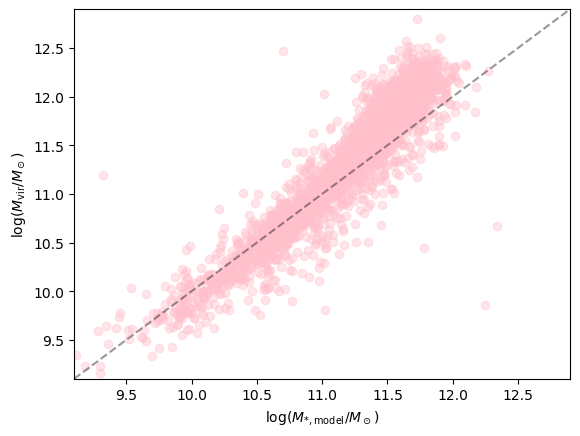

In [16]:
plt.scatter(ellipticals['sphd_M_star'], ellipticals['Mvir'], color='pink', alpha=0.4)
plt.xlim(9.1,12.9)
plt.ylim(9.1,12.9)
plt.plot([9.1,12.9],[9.1,12.9],linestyle='--', color='k', alpha=0.4)
plt.xlabel(r'$\log(M_{*,\rm model}/M_\odot)$')
plt.ylabel(r'$\log(M_{\rm vir}/M_\odot)$')

## split into 4 bins

In [61]:
bins = np.linspace(9.5,12,5)
bin1 = ellipticals[ellipticals['sphd_M_star'] < bins[1]]
bin2 = ellipticals[np.logical_and(ellipticals['sphd_M_star'] > bins[1], ellipticals['sphd_M_star'] < bins[2])]
bin3 = ellipticals[np.logical_and(ellipticals['sphd_M_star'] > bins[2], ellipticals['sphd_M_star'] < bins[3])]
bin4 = ellipticals[ellipticals['sphd_M_star'] > bins[3]]

### cmd for each bin

In [21]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [22]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [23]:
cmd_dict = {1.0: 'b',
            2.0: 'g',
            3.0:'r',
            -99: 'k',
           -1: 'k'}

In [8]:
from matplotlib.lines import Line2D

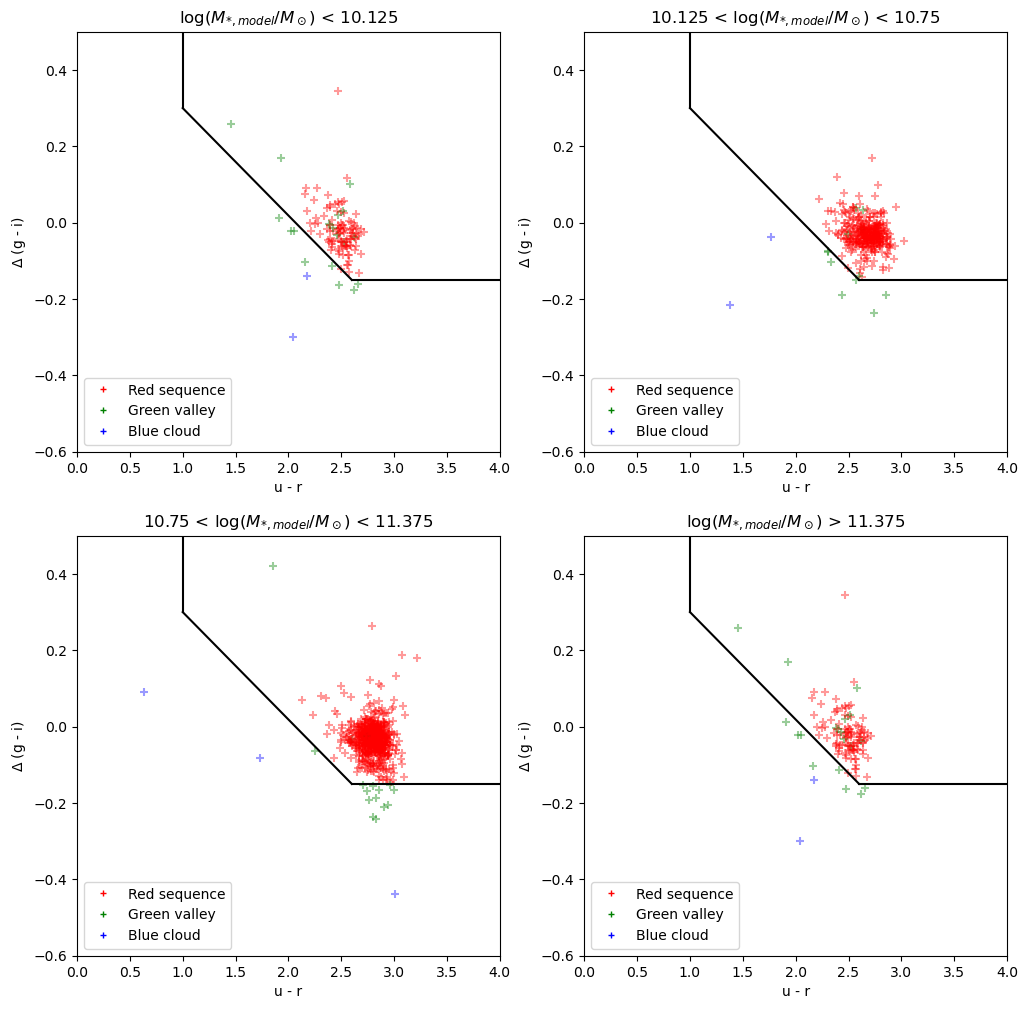

In [38]:
fig, ax = plt.subplots(2,2, figsize=(12,12))

for i in range(len(bin1)):
    nsaid = bin1[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]

    ax[0,0].scatter(nsa_portsmouth['u_r_KIAS'][nsa_idx], nsa_portsmouth['cd'][nsa_idx], marker='+', color=cmd_dict[bin1[i]['CMD_class']],
                    alpha=0.4
               )

ax[0,0].set_xlim(0,4)
ax[0,0].set_ylim(-0.6,0.5)
ax[0,0].set_xlabel('u - r')
ax[0,0].set_ylabel(r'$\Delta$ (g - i)')
ax[0,0].plot([4,2.6],[-0.15,-0.15], color='k')
ax[0,0].plot([2.6,1.0],[-0.15,0.3], color='k')
ax[0,0].plot([1.0,1.0],[0.3,10], color='k')




legend_elements = [Line2D([0], [0], marker='+', color='w', label='Red sequence',
                          markeredgecolor='r', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Green valley',
                          markeredgecolor='g', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Blue cloud',
                          markeredgecolor='b', markersize=5)]


ax[0,0].legend(handles=legend_elements, loc='lower left')
ax[0,0].set_title(r'$\log(M_{*,model}/M_\odot)$ < 10.125')

for i in range(len(bin2)):
    nsaid = bin2[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]

    ax[0,1].scatter(nsa_portsmouth['u_r_KIAS'][nsa_idx], nsa_portsmouth['cd'][nsa_idx], marker='+', color=cmd_dict[bin2[i]['CMD_class']],
                    alpha=0.4
               )

ax[0,1].set_xlim(0,4)
ax[0,1].set_ylim(-0.6,0.5)
ax[0,1].set_xlabel('u - r')
ax[0,1].set_ylabel(r'$\Delta$ (g - i)')
ax[0,1].plot([4,2.6],[-0.15,-0.15], color='k')
ax[0,1].plot([2.6,1.0],[-0.15,0.3], color='k')
ax[0,1].plot([1.0,1.0],[0.3,10], color='k')




legend_elements = [Line2D([0], [0], marker='+', color='w', label='Red sequence',
                          markeredgecolor='r', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Green valley',
                          markeredgecolor='g', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Blue cloud',
                          markeredgecolor='b', markersize=5)]


ax[0,1].legend(handles=legend_elements, loc='lower left')
ax[0,1].set_title(r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75')

for i in range(len(bin3)):
    nsaid = bin3[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]

    ax[1,0].scatter(nsa_portsmouth['u_r_KIAS'][nsa_idx], nsa_portsmouth['cd'][nsa_idx], marker='+', color=cmd_dict[bin3[i]['CMD_class']],
                    alpha=0.4
               )

ax[1,0].set_xlim(0,4)
ax[1,0].set_ylim(-0.6,0.5)
ax[1,0].set_xlabel('u - r')
ax[1,0].set_ylabel(r'$\Delta$ (g - i)')
ax[1,0].plot([4,2.6],[-0.15,-0.15], color='k')
ax[1,0].plot([2.6,1.0],[-0.15,0.3], color='k')
ax[1,0].plot([1.0,1.0],[0.3,10], color='k')




legend_elements = [Line2D([0], [0], marker='+', color='w', label='Red sequence',
                          markeredgecolor='r', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Green valley',
                          markeredgecolor='g', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Blue cloud',
                          markeredgecolor='b', markersize=5)]


ax[1,0].legend(handles=legend_elements, loc='lower left')
ax[1,0].set_title(r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375')

for i in range(len(bin1)):
    nsaid = bin1[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]

    ax[1,1].scatter(nsa_portsmouth['u_r_KIAS'][nsa_idx], nsa_portsmouth['cd'][nsa_idx], marker='+', color=cmd_dict[bin1[i]['CMD_class']],
                    alpha=0.4
               )

ax[1,1].set_xlim(0,4)
ax[1,1].set_ylim(-0.6,0.5)
ax[1,1].set_xlabel('u - r')
ax[1,1].set_ylabel(r'$\Delta$ (g - i)')
ax[1,1].plot([4,2.6],[-0.15,-0.15], color='k')
ax[1,1].plot([2.6,1.0],[-0.15,0.3], color='k')
ax[1,1].plot([1.0,1.0],[0.3,10], color='k')




legend_elements = [Line2D([0], [0], marker='+', color='w', label='Red sequence',
                          markeredgecolor='r', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Green valley',
                          markeredgecolor='g', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Blue cloud',
                          markeredgecolor='b', markersize=5)]


ax[1,1].legend(handles=legend_elements, loc='lower left')
ax[1,1].set_title(r'$\log(M_{*,model}/M_\odot)$ > 11.375')




plt.savefig(plot_dir + 'Mtot_Mstar_bin_CMD.png', bbox_inches='tight')

(9.0, 12.5)

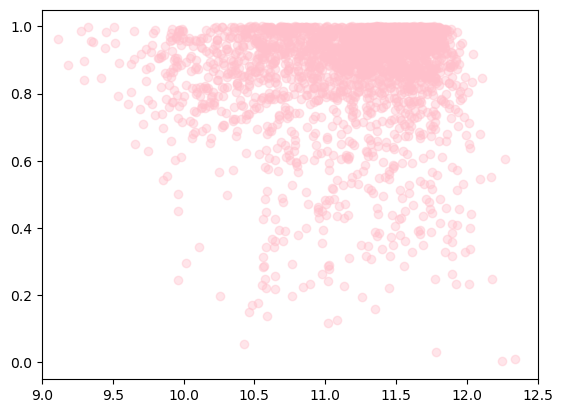

In [41]:
plt.scatter(ellipticals['  '], 10**(ellipticals['e_Mstar_R90'] - ellipticals['sphd_M_star']), color='pink', alpha=0.4)
plt.xlim(9,12.5)
plt.xlabel(

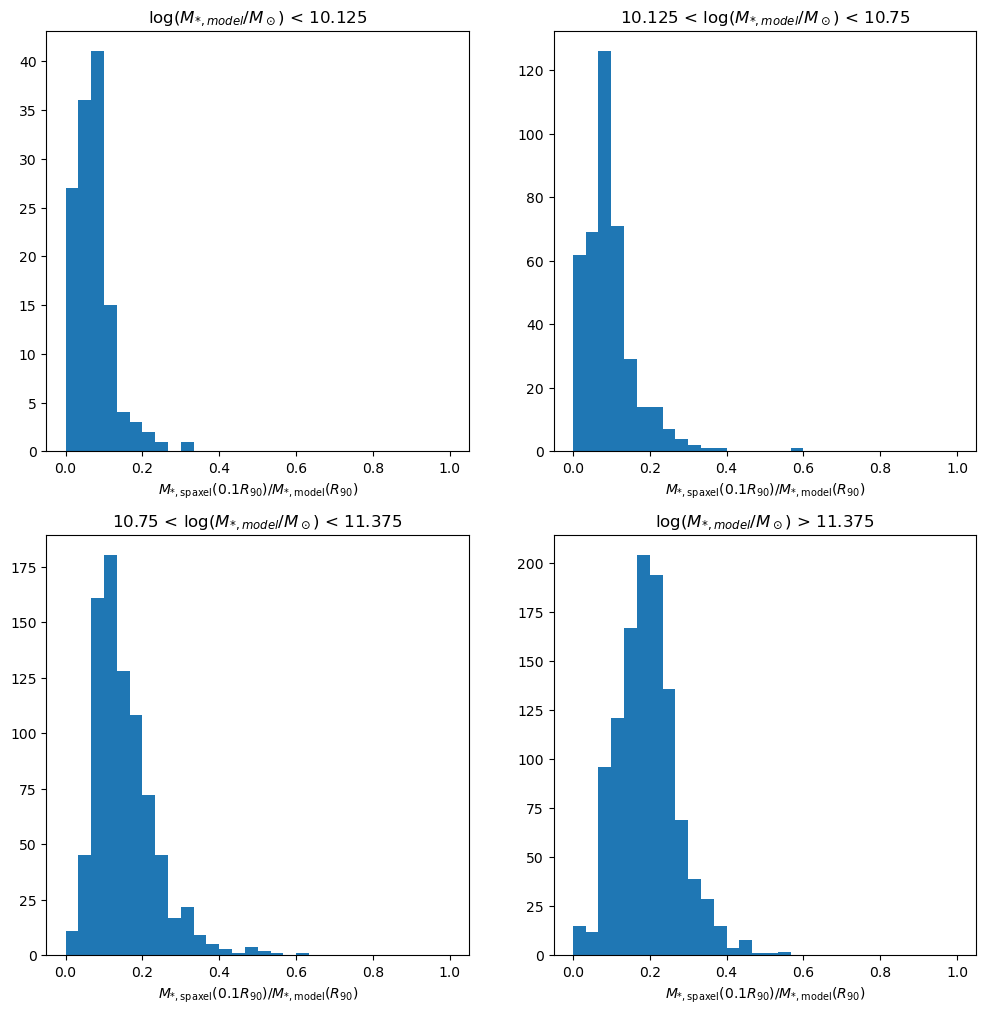

In [24]:
fig, ax = plt.subplots(2,2, figsize=(12,12))

ratio_bins = np.linspace(0,1,31)


ax[0,0].hist(10**(bin1['sum_M_star_0p1_R90']-bin1['e_Mstar_R90']), bins=ratio_bins)
ax[0,0].set_title(r'$\log(M_{*,model}/M_\odot)$ < 10.125')
ax[0,0].set_xlabel(r'$M_{*,\rm spaxel}(0.1R_{90})/M_{*, \rm model}(R_{90})$')


ax[0,1].hist(10**(bin2['sum_M_star_0p1_R90']-bin2['e_Mstar_R90']),bins=ratio_bins)
ax[0,1].set_title(r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75')
ax[0,1].set_xlabel(r'$M_{*,\rm spaxel}(0.1R_{90})/M_{*, \rm model}(R_{90})$')



ax[1,0].hist(10**(bin3['sum_M_star_0p1_R90']-bin3['e_Mstar_R90']),bins=ratio_bins)
ax[1,0].set_title(r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375')
ax[1,0].set_xlabel(r'$M_{*,\rm spaxel}(0.1R_{90})/M_{*, \rm model}(R_{90})$')



ax[1,1].hist(10**(bin4['sum_M_star_0p1_R90']-bin4['e_Mstar_R90']),bins=ratio_bins)
ax[1,1].set_title(r'$\log(M_{*,model}/M_\odot)$ > 11.375')
ax[1,1].set_xlabel(r'$M_{*,\rm spaxel}(0.1R_{90})/M_{*, \rm model}(R_{90})$')

plt.savefig(plot_dir + 'Mtot_Mstar_bin_ratio_hist.png', bbox_inches='tight')

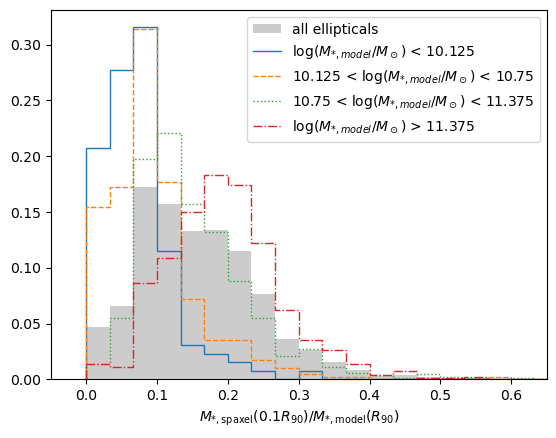

In [23]:
ratio_bins = np.linspace(0,1,31)

counts, bins = np.histogram(10**(ellipticals['sum_M_star_0p1_R90']-ellipticals['e_Mstar_R90']), bins=ratio_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(10**(bin1['sum_M_star_0p1_R90']-bin1['e_Mstar_R90']), bins=ratio_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125')

counts, bins = np.histogram(10**(bin2['sum_M_star_0p1_R90']-bin2['e_Mstar_R90']), bins=ratio_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--')

counts, bins = np.histogram(10**(bin3['sum_M_star_0p1_R90']-bin3['e_Mstar_R90']), bins=ratio_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':')

counts, bins = np.histogram(10**(bin4['sum_M_star_0p1_R90']-bin4['e_Mstar_R90']), bins=ratio_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.')

plt.xlabel(r'$M_{*,\rm spaxel}(0.1R_{90})/M_{*, \rm model}(R_{90})$')

# plt.hist(10**(bin1['sum_M_star_0p1_R90']-bin1['e_Mstar_R90']), bins=ratio_bins, label=r'$\log(M_{*,model}/M_\odot)$ < 10.125', 
#          histtype='step', density=True)

# plt.hist(10**(bin2['sum_M_star_0p1_R90']-bin2['e_Mstar_R90']),bins=ratio_bins, label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75',
#         histtype='step', density=True)

# plt.hist(10**(bin3['sum_M_star_0p1_R90']-bin3['e_Mstar_R90']),bins=ratio_bins, label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375',
#         histtype='step', density=True)

# plt.hist(10**(bin4['sum_M_star_0p1_R90']-bin4['e_Mstar_R90']),bins=ratio_bins, label=r'$\log(M_{*,model}/M_\odot)$ > 11.375',
#          histtype='step', density=True)

plt.legend()
plt.xlim(-0.05, 0.65)

plt.savefig(plot_dir + 'Mtot_Mstar_bin_ratio_hist_stacked.png', bbox_inches='tight')

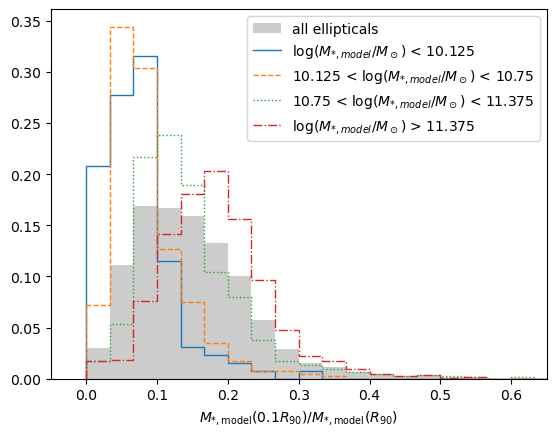

In [12]:
model_0p1 = np.log10(exponential_sphere_disk(ellipticals['R90_kpc']/10, ellipticals['sphd_rho_c'], ellipticals['sphd_R_scale'],
                                    ellipticals['sphd_Sigma_d'], ellipticals['sphd_R_d']))

bin1_0p1 = np.log10(exponential_sphere_disk(bin1['R90_kpc']/10, bin1['sphd_rho_c'], bin1['sphd_R_scale'],
                                    bin1['sphd_Sigma_d'], bin1['sphd_R_d']))
bin2_0p1 = np.log10(exponential_sphere_disk(bin2['R90_kpc']/10, bin2['sphd_rho_c'], bin2['sphd_R_scale'],
                                    bin2['sphd_Sigma_d'], bin2['sphd_R_d']))
bin3_0p1 = np.log10(exponential_sphere_disk(bin3['R90_kpc']/10, bin3['sphd_rho_c'], bin3['sphd_R_scale'],
                                    bin3['sphd_Sigma_d'], bin3['sphd_R_d']))
bin4_0p1 = np.log10(exponential_sphere_disk(bin4['R90_kpc']/10, bin4['sphd_rho_c'], bin4['sphd_R_scale'],
                                    bin4['sphd_Sigma_d'], bin4['sphd_R_d']))

ratio_bins = np.linspace(0,1,31)

counts, bins = np.histogram(10**(model_0p1-ellipticals['e_Mstar_R90']), bins=ratio_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(10**(bin1['sum_M_star_0p1_R90']-bin1['e_Mstar_R90']), bins=ratio_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125')

counts, bins = np.histogram(10**(bin2_0p1-bin2['e_Mstar_R90']), bins=ratio_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--')

counts, bins = np.histogram(10**(bin3_0p1-bin3['e_Mstar_R90']), bins=ratio_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':')

counts, bins = np.histogram(10**(bin4_0p1-bin4['e_Mstar_R90']), bins=ratio_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.')

plt.xlabel(r'$M_{*,\rm model}(0.1R_{90})/M_{*, \rm model}(R_{90})$')



plt.legend()
plt.xlim(-0.05, 0.65)

plt.savefig(plot_dir + 'Mtot_Mstar_model_bin_ratio_hist_stacked.png', bbox_inches='tight')

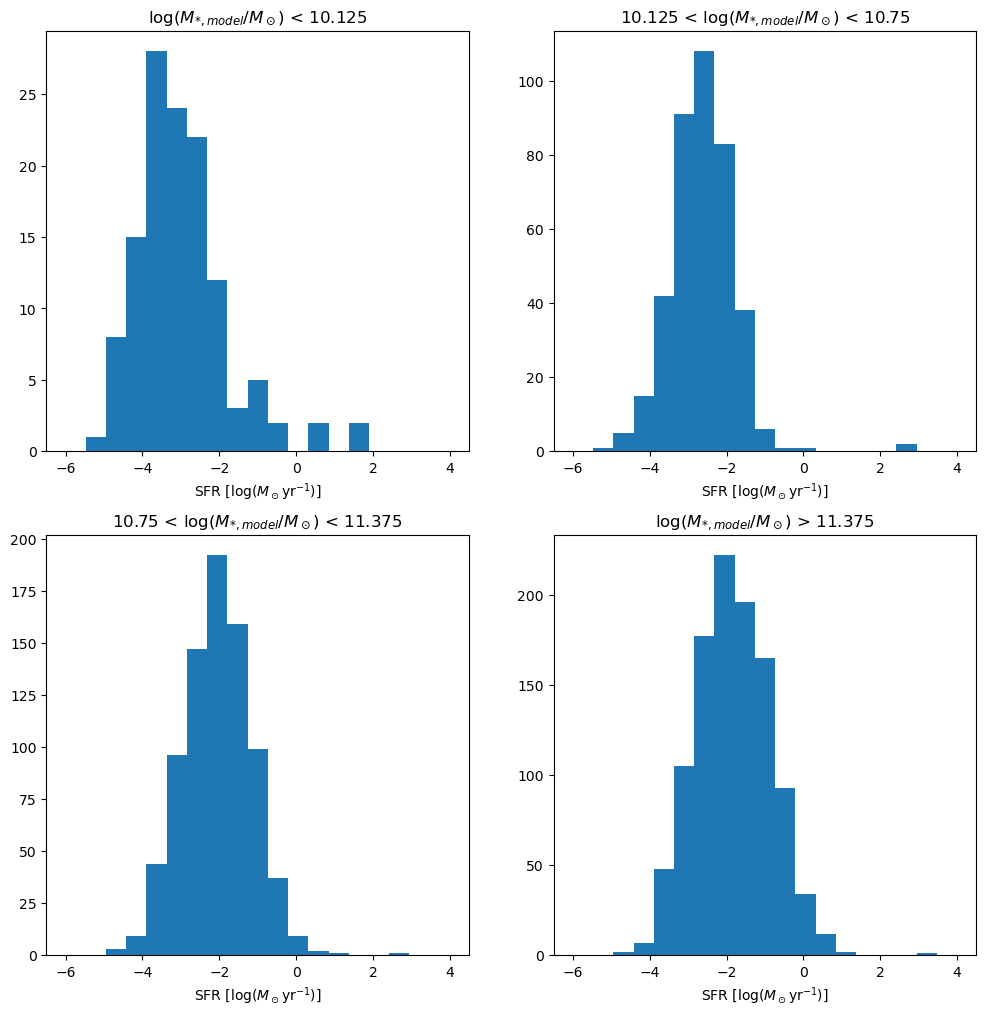

In [35]:
fig, ax = plt.subplots(2,2, figsize=(12,12))

sfr_bins = np.linspace(-6,4,20)


ax[0,0].hist(bin1['SFR'], bins=sfr_bins)
ax[0,0].set_title(r'$\log(M_{*,model}/M_\odot)$ < 10.125')
ax[0,0].set_xlabel(r'SFR [$\log(M_\odot \rm yr^{-1})$]')


ax[0,1].hist(bin2['SFR'], bins=sfr_bins)
ax[0,1].set_title(r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75')
ax[0,1].set_xlabel(r'SFR [$\log(M_\odot \rm yr^{-1})$]')



ax[1,0].hist(bin3['SFR'], bins=sfr_bins)
ax[1,0].set_title(r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375')
ax[1,0].set_xlabel(r'SFR [$\log(M_\odot \rm yr^{-1})$]')



ax[1,1].hist(bin4['SFR'], bins=sfr_bins)
ax[1,1].set_title(r'$\log(M_{*,model}/M_\odot)$ > 11.375')
ax[1,1].set_xlabel(r'SFR [$\log(M_\odot \rm yr^{-1})$]')

plt.savefig(plot_dir + 'Mtot_Mstar_bin_SFR_hist.png', bbox_inches='tight')

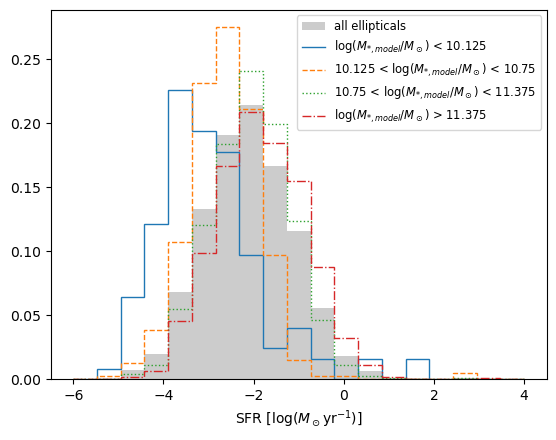

In [27]:
sfr_bins = np.linspace(-6,4,20)

counts, bins = np.histogram(ellipticals['SFR'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(bin1['SFR'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125')

counts, bins = np.histogram(bin2['SFR'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--')

counts, bins = np.histogram(bin3['SFR'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':')

counts, bins = np.histogram(bin4['SFR'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.')


plt.xlabel(r'SFR [$\log(M_\odot \rm yr^{-1})$]')
plt.legend(fontsize='small')

plt.savefig(plot_dir + 'Mtot_Mstar_bin_SFR_hist_stacked.png', bbox_inches='tight')

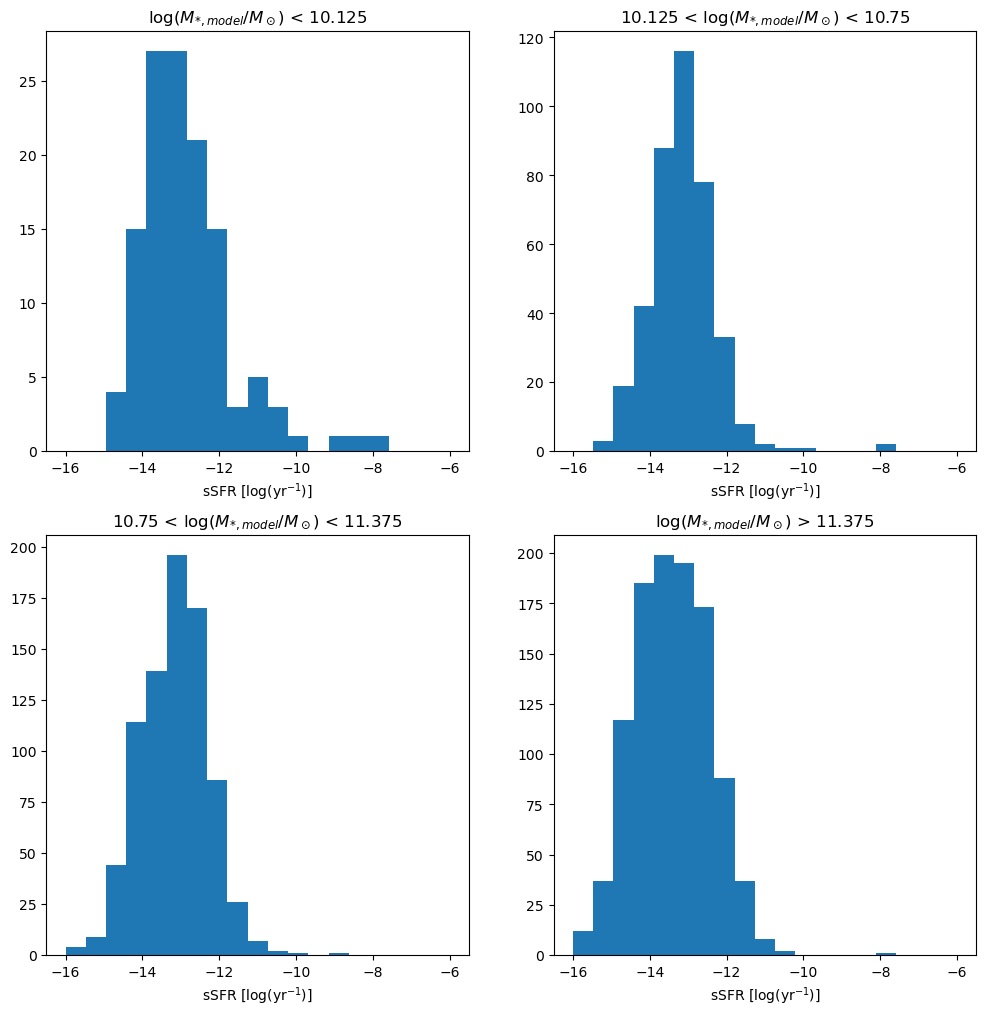

In [10]:
fig, ax = plt.subplots(2,2, figsize=(12,12))

sfr_bins = np.linspace(-16,-6,20)


ax[0,0].hist(bin1['SFR'] - bin1['sphd_M_star'], 
             bins=sfr_bins
            )
ax[0,0].set_title(r'$\log(M_{*,model}/M_\odot)$ < 10.125')
ax[0,0].set_xlabel(r'sSFR [$\log(\rm yr^{-1})$]')


ax[0,1].hist(bin2['SFR'] - bin2['sphd_M_star'], 
             bins=sfr_bins
            )
ax[0,1].set_title(r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75')
ax[0,1].set_xlabel(r'sSFR [$\log(\rm yr^{-1})$]')



ax[1,0].hist(bin3['SFR'] - bin3['sphd_M_star'], 
             bins=sfr_bins
            )
ax[1,0].set_title(r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375')
ax[1,0].set_xlabel(r'sSFR [$\log(\rm yr^{-1})$]')



ax[1,1].hist(bin4['SFR'] - bin4['sphd_M_star'], 
             bins=sfr_bins
            )
ax[1,1].set_title(r'$\log(M_{*,model}/M_\odot)$ > 11.375')
ax[1,1].set_xlabel(r'sSFR [$\log(\rm yr^{-1})$]')

plt.savefig(plot_dir + 'Mtot_Mstar_bin_sSFR_hist.png', bbox_inches='tight')

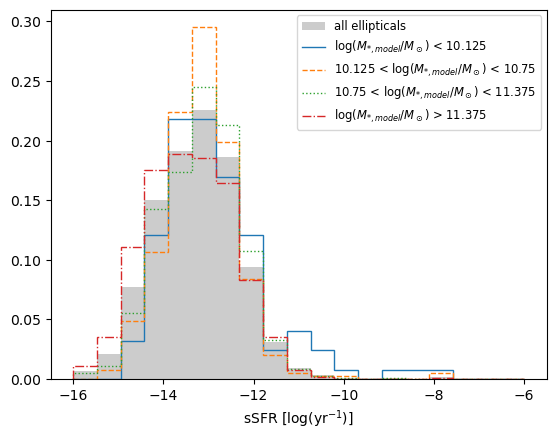

In [11]:
sfr_bins = np.linspace(-16,-6,20)

counts, bins = np.histogram(ellipticals['SFR'] - ellipticals['sphd_M_star'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(bin1['SFR']- bin1['sphd_M_star'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125')

counts, bins = np.histogram(bin2['SFR'] - bin2['sphd_M_star'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--')

counts, bins = np.histogram(bin3['SFR'] - bin3['sphd_M_star'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':')

counts, bins = np.histogram(bin4['SFR'] - bin4['sphd_M_star'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.')


plt.legend(fontsize='small')

plt.xlabel(r'sSFR [$\log(\rm yr^{-1})$]')

plt.savefig(plot_dir + 'Mtot_Mstar_bin_sSFR_hist_stacked.png', bbox_inches='tight')

Text(0.5, 0, 'sSFR [$\\log(\\rm yr^{-1})$]')

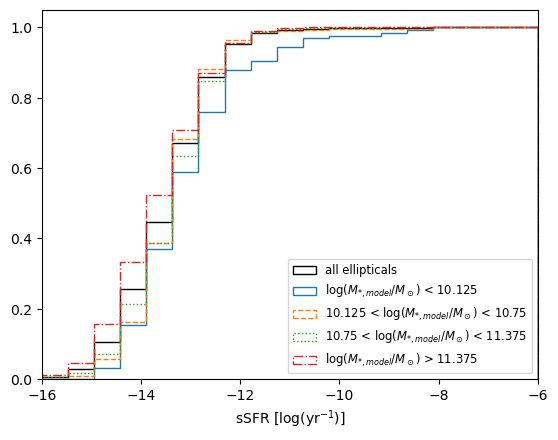

In [23]:
sfr_bins = np.linspace(-16,-6,20)

# counts, bins = np.histogram(ellipticals['SFR'] - ellipticals['sphd_M_star'], bins=sfr_bins)
# plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')

plt.hist(ellipticals['SFR'] - ellipticals['sphd_M_star'], bins=sfr_bins, density=True, cumulative=True, histtype='step',
         label=r'all ellipticals', color='k')
plt.hist(bin1['SFR']- bin1['sphd_M_star'], bins=sfr_bins, color='tab:blue', density=True, cumulative=True, histtype='step',
           label=r'$\log(M_{*,model}/M_\odot)$ < 10.125')
plt.hist(bin2['SFR'] - bin2['sphd_M_star'], bins=sfr_bins, color='tab:orange',density=True, cumulative=True, histtype='step',
           label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--')
plt.hist(bin3['SFR'] - bin3['sphd_M_star'], bins=sfr_bins, color='tab:green', density=True, cumulative=True, histtype='step',
           label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':')
plt.hist(bin4['SFR'] - bin4['sphd_M_star'], bins=sfr_bins, color='tab:red', density=True, cumulative=True, histtype='step',
           label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.')

plt.xlim(-16,-6)

# counts, bins = np.histogram(bin1['SFR']- bin1['sphd_M_star'], bins=sfr_bins)
# plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125')

# counts, bins = np.histogram(bin2['SFR'] - bin2['sphd_M_star'], bins=sfr_bins)
# plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--')

# counts, bins = np.histogram(bin3['SFR'] - bin3['sphd_M_star'], bins=sfr_bins)
# plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':')

# counts, bins = np.histogram(bin4['SFR'] - bin4['sphd_M_star'], bins=sfr_bins)
# plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.')


plt.legend(fontsize='small')

plt.xlabel(r'sSFR [$\log(\rm yr^{-1})$]')

# plt.savefig(plot_dir + 'Mtot_Mstar_bin_sSFR_hist_stacked.png', bbox_inches='tight')

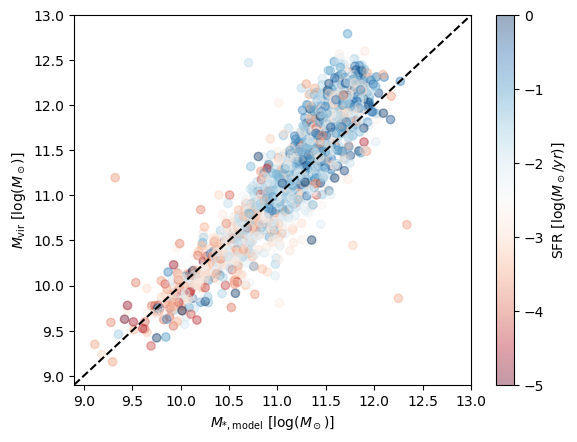

In [55]:
plt.scatter(ellipticals['sphd_M_star'], ellipticals['Mvir'], c=ellipticals['SFR'], 
            vmin=-5, vmax=0, 
            alpha=0.4,
           cmap='RdBu')
plt.colorbar(label=r'SFR $[\log(M_\odot/yr)]$')
plt.xlim(8.9,13)
plt.ylim(8.9,13)
plt.plot([8.9,13],[8.9,13], color='k', linestyle='--')
plt.xlabel(r'$M_{*, \rm model}\ [\log(M_\odot)]$')
plt.ylabel(r'$M_{\rm vir}\ [\log(M_\odot)]$')
plt.savefig(plot_dir + 'Mtot_Mstar_SFRcolor.png', bbox_inches='tight')

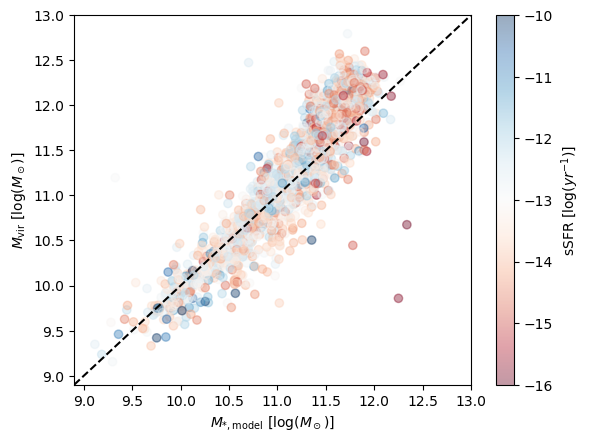

In [34]:
plt.scatter(ellipticals['sphd_M_star'], ellipticals['Mvir'], c=ellipticals['SFR'] - ellipticals['sphd_M_star'], 
            vmin=-16, vmax=-10, 
            alpha=0.4,
           cmap='RdBu')
plt.colorbar(label=r'sSFR $[\log(yr^{-1})]$')
plt.xlim(8.9,13)
plt.ylim(8.9,13)
plt.plot([8.9,13],[8.9,13], color='k', linestyle='--')
plt.xlabel(r'$M_{*, \rm model}\ [\log(M_\odot)]$')
plt.ylabel(r'$M_{\rm vir}\ [\log(M_\odot)]$')
plt.savefig(plot_dir + 'Mtot_Mstar_sSFRcolor.png', bbox_inches='tight')

In [24]:
p3d = Table.read(DATA_FOLDER + 'SDSS17Pipe3D_v3_1_1.fits', format='fits')
p3d[:5]

name,plate,ifudsgn,plateifu,mangaid,objra,objdec,log_SFR_Ha,FoV,Re_kpc,e_log_Mass,e_log_SFR_Ha,log_Mass,log_SFR_ssp,log_NII_Ha_cen,e_log_NII_Ha_cen,log_OIII_Hb_cen,e_log_OIII_Hb_cen,log_SII_Ha_cen,e_log_SII_Ha_cen,log_OII_Hb_cen,e_log_OII_Hb_cen,EW_Ha_cen,e_EW_Ha_cen,ZH_LW_Re_fit,e_ZH_LW_Re_fit,alpha_ZH_LW_Re_fit,e_alpha_ZH_LW_Re_fit,ZH_MW_Re_fit,e_ZH_MW_Re_fit,alpha_ZH_MW_Re_fit,e_alpha_ZH_MW_Re_fit,Age_LW_Re_fit,e_Age_LW_Re_fit,alpha_Age_LW_Re_fit,e_alpha_Age_LW_Re_fit,Age_MW_Re_fit,e_Age_MW_Re_fit,alpha_Age_MW_Re_fit,e_alpha_Age_MW_Re_fit,Re_arc,DL,DA,PA,ellip,log_Mass_gas,vel_sigma_Re,e_vel_sigma_Re,log_SFR_SF,log_SFR_D_C,OH_O3N2_cen,e_OH_O3N2_cen,OH_N2_cen,e_OH_N2_cen,OH_ONS_cen,e_OH_ONS_cen,OH_R23_cen,e_OH_R23_cen,OH_pyqz_cen,e_OH_pyqz_cen,OH_t2_cen,e_OH_t2_cen,OH_M08_cen,e_OH_M08_cen,OH_T04_cen,e_OH_T04_cen,OH_dop_cen,e_OH_dop_cen,OH_O3N2_EPM09_cen,e_OH_O3N2_EPM09_cen,log_OI_Ha_cen,e_log_OI_Ha_cen,Ha_Hb_cen,e_Ha_Hb_cen,log_NII_Ha_Re,e_log_NII_Ha_Re,log_OIII_Hb_Re,e_log_OIII_Hb_Re,log_SII_Ha_Re,e_log_SII_Ha_Re,log_OII_Hb_Re,e_log_OII_Hb_Re,log_OI_Ha_Re,e_log_OI_Ha_Re,EW_Ha_Re,e_EW_Ha_Re,Ha_Hb_Re,e_Ha_Hb_Re,log_NII_Ha_ALL,e_log_NII_Ha_ALL,log_OIII_Hb_ALL,e_log_OIII_Hb_ALL,log_SII_Ha_ALL,e_log_SII_Ha_ALL,log_OII_Hb_ALL,e_log_OII_Hb_ALL,log_OI_Ha_ALL,e_log_OI_Ha_ALL,EW_Ha_ALL,e_EW_Ha_ALL,Ha_Hb_ALL,Sigma_Mass_cen,e_Sigma_Mass_cen,Sigma_Mass_Re,e_Sigma_Mass_Re,Sigma_Mass_ALL,e_Sigma_Mass_ALL,T30,ZH_T30,ZH_Re_T30,a_ZH_T30,T40,ZH_T40,ZH_Re_T40,a_ZH_T40,T50,ZH_T50,ZH_Re_T50,a_ZH_T50,T60,ZH_T60,ZH_Re_T60,a_ZH_T60,T70,ZH_T70,ZH_Re_T70,a_ZH_T70,T80,ZH_T80,ZH_Re_T80,a_ZH_T80,T90,ZH_T90,ZH_Re_T90,a_ZH_T90,T95,ZH_T95,ZH_Re_T95,a_ZH_T95,T99,ZH_T99,ZH_Re_T99,a_ZH_T99,log_Mass_gas_Av_gas_OH,log_Mass_gas_Av_ssp_OH,vel_ssp_2,e_vel_ssp_2,vel_Ha_2,e_vel_Ha_2,vel_ssp_1,e_vel_ssp_1,vel_Ha_1,e_vel_Ha_1,log_SFR_ssp_100Myr,log_SFR_ssp_10Myr,vel_disp_Ha_cen,vel_disp_ssp_cen,vel_disp_Ha_1Re,vel_disp_ssp_1Re,log_Mass_in_Re,ML_int,ML_avg,F_Ha_cen,e_F_Ha_cen,R50_kpc_V,e_R50_kpc_V,R50_kpc_Mass,e_R50_kpc_Mass,log_Mass_corr_in_R50_V,e_log_Mass_corr_in_R50_V,log_Mass_gas_Av_gas_log_log,Av_gas_Re,e_Av_gas_Re,Av_ssp_Re,e_Av_ssp_Re,Lambda_Re,e_Lambda_Re,nsa_redshift,nsa_mstar,nsa_inclination,flux_[OII]3726.03_Re_fit,e_flux_[OII]3726.03_Re_fit,flux_[OII]3726.03_alpha_fit,e_flux_[OII]3726.03_alpha_fit,flux_[OII]3728.82_Re_fit,e_flux_[OII]3728.82_Re_fit,flux_[OII]3728.82_alpha_fit,e_flux_[OII]3728.82_alpha_fit,flux_HI3734.37_Re_fit,e_flux_HI3734.37_Re_fit,flux_HI3734.37_alpha_fit,e_flux_HI3734.37_alpha_fit,flux_HI3797.9_Re_fit,e_flux_HI3797.9_Re_fit,flux_HI3797.9_alpha_fit,e_flux_HI3797.9_alpha_fit,flux_HeI3888.65_Re_fit,e_flux_HeI3888.65_Re_fit,flux_HeI3888.65_alpha_fit,e_flux_HeI3888.65_alpha_fit,flux_HI3889.05_Re_fit,e_flux_HI3889.05_Re_fit,flux_HI3889.05_alpha_fit,e_flux_HI3889.05_alpha_fit,flux_HeI3964.73_Re_fit,e_flux_HeI3964.73_Re_fit,flux_HeI3964.73_alpha_fit,e_flux_HeI3964.73_alpha_fit,flux_[NeIII]3967.46_Re_fit,e_flux_[NeIII]3967.46_Re_fit,flux_[NeIII]3967.46_alpha_fit,e_flux_[NeIII]3967.46_alpha_fit,flux_CaII3968.47_Re_fit,e_flux_CaII3968.47_Re_fit,flux_CaII3968.47_alpha_fit,e_flux_CaII3968.47_alpha_fit,flux_Hepsilon3970.07_Re_fit,e_flux_Hepsilon3970.07_Re_fit,flux_Hepsilon3970.07_alpha_fit,e_flux_Hepsilon3970.07_alpha_fit,flux_Hdelta4101.77_Re_fit,e_flux_Hdelta4101.77_Re_fit,flux_Hdelta4101.77_alpha_fit,e_flux_Hdelta4101.77_alpha_fit,flux_Hgamma4340.49_Re_fit,e_flux_Hgamma4340.49_Re_fit,flux_Hgamma4340.49_alpha_fit,e_flux_Hgamma4340.49_alpha_fit,flux_Hbeta4861.36_Re_fit,e_flux_Hbeta4861.36_Re_fit,flux_Hbeta4861.36_alpha_fit,e_flux_Hbeta4861.36_alpha_fit,flux_[OIII]4958.91_Re_fit,e_flux_[OIII]4958.91_Re_fit,flux_[OIII]4958.91_alpha_fit,e_flux_[OIII]4958.91_alpha_fit,flux_[OIII]5006.84_Re_fit,e_flux_[OIII]5006.84_Re_fit,flux_[OIII]5006.84_alpha_fit,e_flux_[OIII]5006.84_alpha_fit,flux_HeI5015.68_Re_fit,e_flux_HeI5015.68_Re_fit,flux_HeI5015.68_alpha_fit,e_flux_HeI5015.68_alpha_fit,flux_[NI]5197.9_Re_fit,e_flux_[NI]5197.9_Re_fit,flux_[NI]5197.9_alpha_fit

In [25]:
p3d_dict = {}
for i in range(len(p3d)):
    p3d_dict[p3d[i]['plateifu']] = i

10496-3704
10514-1902
10837-12702
11980-3703
12678-3702
12683-1902
7972-1902
8481-1901
9514-6102


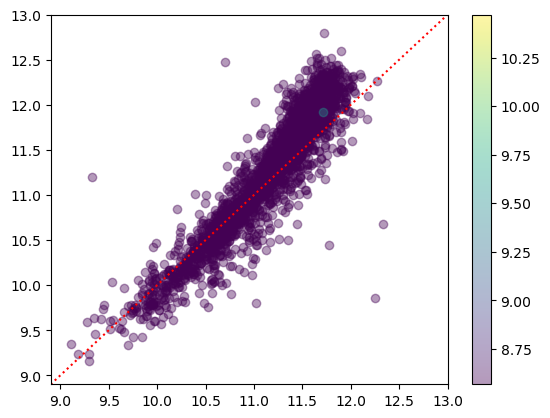

In [34]:
for i in range(len(ellipticals)):

    try:

        i_p = p3d_dict[ellipticals[i]['plateifu']]
    
        plt.scatter(ellipticals['sphd_M_star'][i], ellipticals['Mvir'][i], 
                c=p3d[i_p]['Age_LW_Re_fit'], # vmin = 8.5, vmax=10,
                alpha=0.4)
    except:
        print(ellipticals[i]['plateifu'])

plt.colorbar()

plt.xlim(8.9,13)
plt.ylim(8.9,13)
plt.plot([8.9,13],[8.9,13], color='r', linestyle=':')

In [30]:
p3d[0]['plateifu']

'10001-12701'

(array([1.000e+00, 8.000e+00, 3.600e+01, 1.700e+02, 1.027e+03, 1.709e+03,
        1.538e+03, 1.369e+03, 1.978e+03, 2.340e+03]),
 array([7.47825293, 7.72049396, 7.96273499, 8.20497602, 8.44721705,
        8.68945807, 8.9316991 , 9.17394013, 9.41618116, 9.65842219,
        9.90066322]),
 <BarContainer object of 10 artists>)

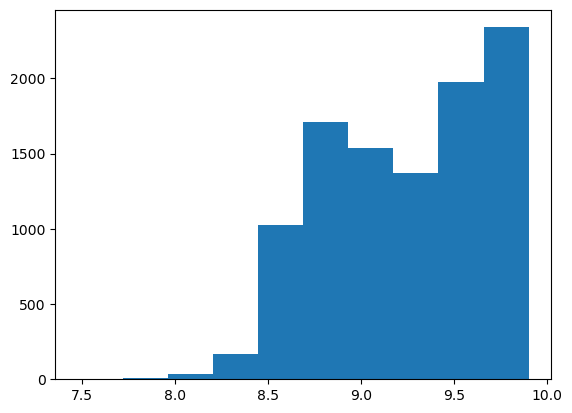

In [35]:
plt.hist(p3d['Age_LW_Re_fit'])

In [47]:
ellipticals['Age_LW_Re_fit'] = -99.
ellipticals['Age_MW_Re_fit'] = -99.
ellipticals['ZH_LW_Re_fit'] = -99.
ellipticals['ZH_MW_Re_fit'] = -99.

for i in range(len(ellipticals)):

    try:

        i_p = p3d_dict[ellipticals[i]['plateifu']]

        ellipticals['Age_LW_Re_fit'][i] = p3d[i_p]['Age_LW_Re_fit']
        ellipticals['Age_MW_Re_fit'][i] = p3d[i_p]['Age_MW_Re_fit']
        ellipticals['ZH_LW_Re_fit'][i] = p3d[i_p]['ZH_LW_Re_fit']
        ellipticals['ZH_MW_Re_fit'][i] = p3d[i_p]['ZH_MW_Re_fit']
    
    except:
        print(ellipticals[i]['plateifu'])

10496-3704
10837-12702
11980-3703
12678-3702
12683-1902
9514-6102


/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/astropy/table/column.py:1376: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value


(array([  0.,   0.,   4.,   5.,   3.,   8.,   5.,   7.,  11.,  24.,  47.,
         70., 114., 250., 569., 888., 412.,  30.,   0.]),
 array([ 8.5       ,  8.57894737,  8.65789474,  8.73684211,  8.81578947,
         8.89473684,  8.97368421,  9.05263158,  9.13157895,  9.21052632,
         9.28947368,  9.36842105,  9.44736842,  9.52631579,  9.60526316,
         9.68421053,  9.76315789,  9.84210526,  9.92105263, 10.        ]),
 <BarContainer object of 19 artists>)

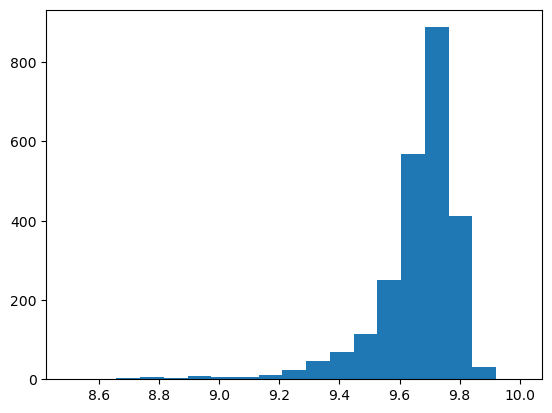

In [48]:
plt.hist(ellipticals['Age_LW_Re_fit'], bins=np.linspace(8.5,10,20))

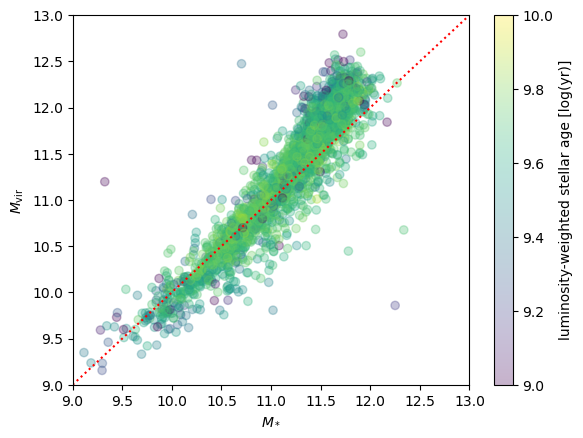

In [57]:
plt.scatter(ellipticals['sphd_M_star'], ellipticals['Mvir'], c=ellipticals['Age_LW_Re_fit'], vmin=9, vmax=10,alpha=0.3)
plt.colorbar(label='luminosity-weighted stellar age [log(yr)]')
plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{\rm vir}$')
plt.xlim(9,13)
plt.ylim(9,13)
plt.plot([9,13],[9,13], color='r', linestyle=':')

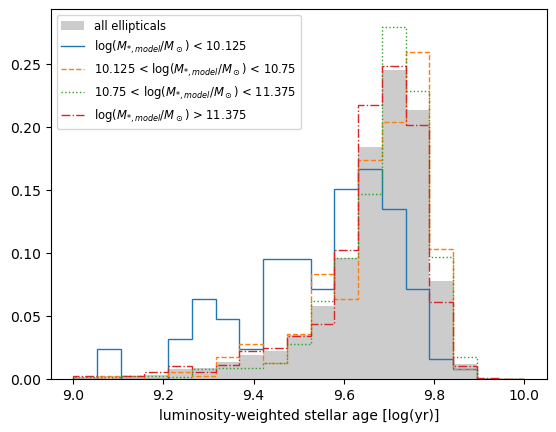

In [63]:
age_bins = np.linspace(9,10,20)

counts, bins = np.histogram(ellipticals['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(bin1['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125')

counts, bins = np.histogram(bin2['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--')

counts, bins = np.histogram(bin3['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':')

counts, bins = np.histogram(bin4['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.')


plt.xlabel(r'luminosity-weighted stellar age [log(yr)]')
plt.legend(fontsize='small')

plt.savefig(plot_dir + 'Mtot_Mstar_bin_LW_age_hist_stacked.png', bbox_inches='tight')

(array([  1.,   0.,   0.,   1.,   2.,   6.,   4.,  26.,  20.,  27.,  60.,
         99., 164., 274., 378., 543., 503., 275.,  64.]),
 array([ 9.2       ,  9.24210526,  9.28421053,  9.32631579,  9.36842105,
         9.41052632,  9.45263158,  9.49473684,  9.53684211,  9.57894737,
         9.62105263,  9.66315789,  9.70526316,  9.74736842,  9.78947368,
         9.83157895,  9.87368421,  9.91578947,  9.95789474, 10.        ]),
 <BarContainer object of 19 artists>)

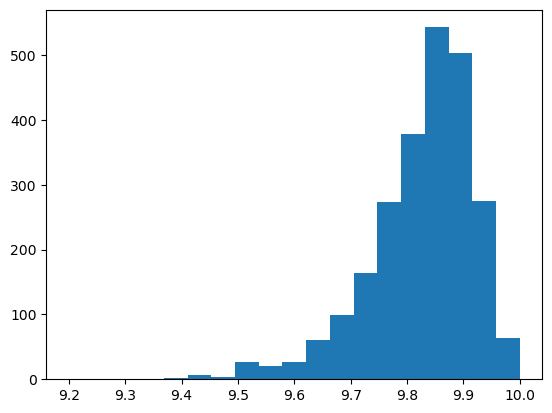

In [49]:
plt.hist(ellipticals['Age_MW_Re_fit'], 
         bins=np.linspace(9.2,10,20)
        )

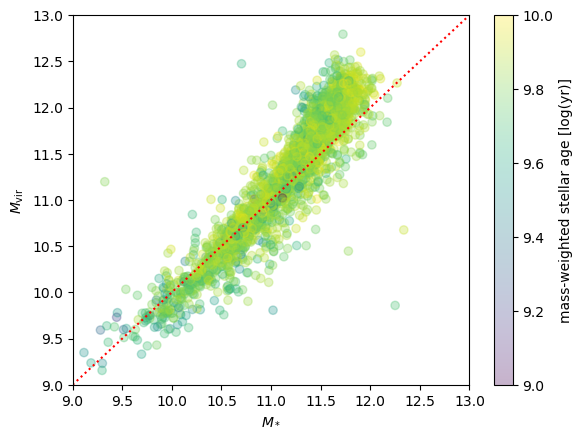

In [58]:
plt.scatter(ellipticals['sphd_M_star'], ellipticals['Mvir'], c=ellipticals['Age_MW_Re_fit'], vmin=9, vmax=10,alpha=0.3)
plt.colorbar(label='mass-weighted stellar age [log(yr)]')
plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{\rm vir}$')
plt.xlim(9,13)
plt.ylim(9,13)
plt.plot([9,13],[9,13], color='r', linestyle=':')

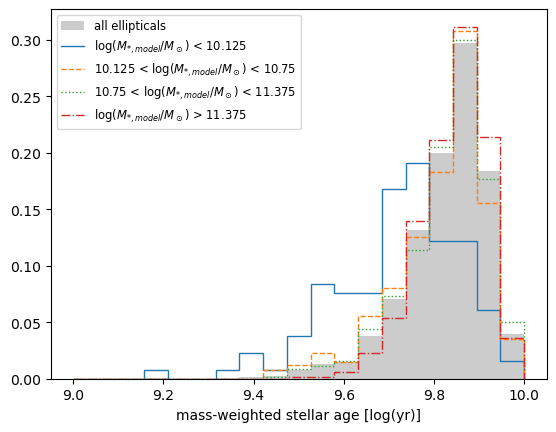

In [65]:
age_bins = np.linspace(9,10,20)

counts, bins = np.histogram(ellipticals['Age_MW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(bin1['Age_MW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125')

counts, bins = np.histogram(bin2['Age_MW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--')

counts, bins = np.histogram(bin3['Age_MW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':')

counts, bins = np.histogram(bin4['Age_MW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.')


plt.xlabel(r'mass-weighted stellar age [log(yr)]')
plt.legend(fontsize='small')

plt.savefig(plot_dir + 'Mtot_Mstar_bin_MW_age_hist_stacked.png', bbox_inches='tight')

(array([ 14.,  24.,  61.,  96., 187., 382., 611., 701., 320.,  55.]),
 array([-0.52882341, -0.45723168, -0.38563995, -0.31404822, -0.24245649,
        -0.17086477, -0.09927304, -0.02768131,  0.04391042,  0.11550215,
         0.18709388]),
 <BarContainer object of 10 artists>)

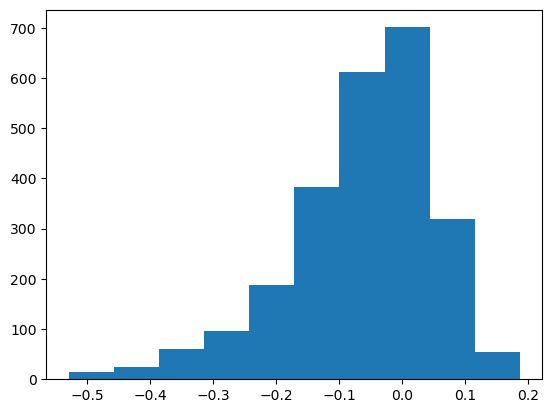

In [51]:
plt.hist(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99])

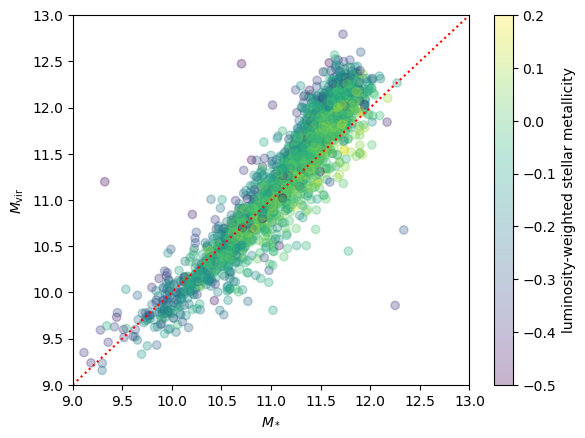

In [59]:
plt.scatter(ellipticals['sphd_M_star'], ellipticals['Mvir'], c=ellipticals['ZH_LW_Re_fit'], vmin=-0.5, vmax=0.2,alpha=0.3)
plt.colorbar(label='luminosity-weighted stellar metallicity')
plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{\rm vir}$')
plt.xlim(9,13)
plt.ylim(9,13)
plt.plot([9,13],[9,13], color='r', linestyle=':')

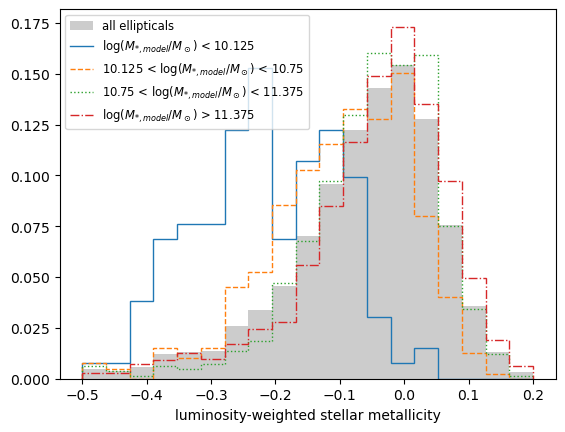

In [66]:
age_bins = np.linspace(-0.5,0.2,20)

counts, bins = np.histogram(ellipticals['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(bin1['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125')

counts, bins = np.histogram(bin2['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--')

counts, bins = np.histogram(bin3['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':')

counts, bins = np.histogram(bin4['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.')


plt.xlabel(r'luminosity-weighted stellar metallicity')
plt.legend(fontsize='small')

plt.savefig(plot_dir + 'Mtot_Mstar_bin_LW_Z_hist_stacked.png', bbox_inches='tight')

(array([2.000e+00, 1.000e+00, 3.000e+00, 4.000e+00, 4.000e+00, 2.400e+01,
        1.230e+02, 5.540e+02, 1.392e+03, 3.430e+02]),
 array([-1.26830304, -1.11652577, -0.9647485 , -0.81297122, -0.66119395,
        -0.50941667, -0.3576394 , -0.20586213, -0.05408485,  0.09769242,
         0.2494697 ]),
 <BarContainer object of 10 artists>)

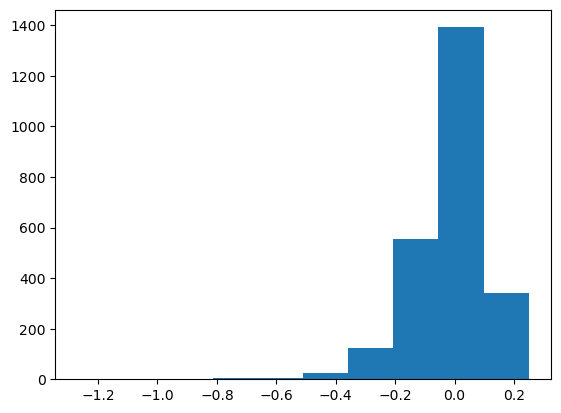

In [52]:
plt.hist(ellipticals['ZH_MW_Re_fit'][ellipticals['ZH_MW_Re_fit']>-99])

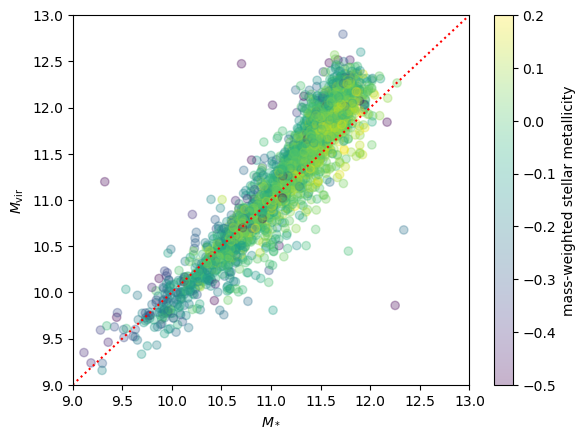

In [60]:
plt.scatter(ellipticals['sphd_M_star'], ellipticals['Mvir'], c=ellipticals['ZH_MW_Re_fit'], vmin=-0.5, vmax=0.2,alpha=0.3)
plt.colorbar(label='mass-weighted stellar metallicity')
plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{\rm vir}$')
plt.xlim(9,13)
plt.ylim(9,13)
plt.plot([9,13],[9,13], color='r', linestyle=':')

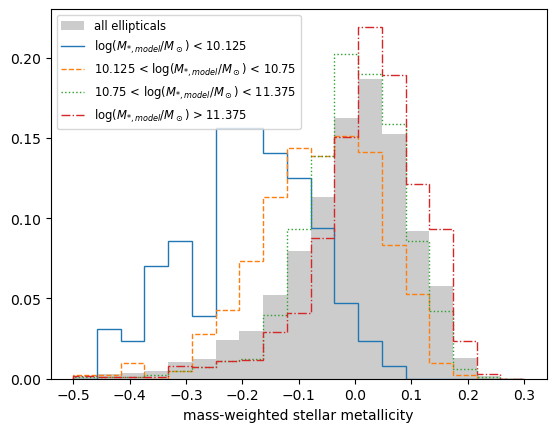

In [67]:
age_bins = np.linspace(-0.5,0.3,20)

counts, bins = np.histogram(ellipticals['ZH_MW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(bin1['ZH_MW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125')

counts, bins = np.histogram(bin2['ZH_MW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--')

counts, bins = np.histogram(bin3['ZH_MW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':')

counts, bins = np.histogram(bin4['ZH_MW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.')


plt.xlabel(r'mass-weighted stellar metallicity')
plt.legend(fontsize='small')

plt.savefig(plot_dir + 'Mtot_Mstar_bin_MW_Z_hist_stacked.png', bbox_inches='tight')